# Missing Analysis

## Rules
- Features: remove columns with missing ratio > 50%
- Students: after feature filtering, remove rows with missing ratio > 0%
- Final output: out/features.csv (0% missing)

In [4]:
import pandas as pd
from pathlib import Path

# Config
feature_threshold = 50
student_threshold = 0

# Resolve paths from either project root or data_cleaning folder
candidate_input_paths = [
    Path('out/engineered_features_rq.csv'),
    Path('../out/engineered_features_rq.csv')
]
input_csv_path = next((p for p in candidate_input_paths if p.exists()), None)
if input_csv_path is None:
    tried_paths = ', '.join(str(p) for p in candidate_input_paths)
    raise FileNotFoundError(f'Cannot find engineered_features_rq.csv. Tried: {tried_paths}')

output_csv_path = input_csv_path.parent / 'features.csv'
input_csv = str(input_csv_path)
output_csv = str(output_csv_path)

# Load data
df = pd.read_csv(input_csv)
print(f'Loaded data shape: {df.shape}')
print(f'Input CSV path: {input_csv_path.resolve()}')
print(f'Output CSV path: {output_csv_path.resolve()}')

# Feature-level missing analysis
feature_missing_ratio = (df.isnull().mean() * 100).sort_values(ascending=False)
feature_summary = pd.DataFrame({
    'Feature': feature_missing_ratio.index,
    'Missing Ratio (%)': feature_missing_ratio.values
})
feature_summary['Category'] = pd.cut(
    feature_summary['Missing Ratio (%)'],
    bins=[-0.01, 25, 50, 100],
    labels=['<=25%', '25-50%', '>50%']
)

display(feature_summary)

Loaded data shape: (1781, 35)
Input CSV path: /home/dicksonyu1230/exchange/MLBD/CS_421_MLBD/out/engineered_features_rq.csv
Output CSV path: /home/dicksonyu1230/exchange/MLBD/CS_421_MLBD/out/features.csv


,Feature,Missing Ratio (%),Category
0,knowledge_component_gain,100.000000,>50%
1,hard_question_score_ratio,68.725435,>50%
2,repeated_question_views,55.081415,>50%
3,total_question_views,55.081415,>50%
4,unique_questions_viewed,55.081415,>50%
5,question_review_rate,55.081415,>50%
6,chatbot_prompt_effort_chars,43.009545,25-50%
7,chatbot_user_messages_per_thread,43.009545,25-50%
8,chatbot_session_depth,43.009545,25-50%
9,replay_per_video,33.239753,25-50%


In [5]:
# Student-level missing analysis after feature filtering
features_to_drop = feature_summary.loc[
    feature_summary['Missing Ratio (%)'] > feature_threshold,
    'Feature'
].tolist()

df_after_feature_filter = df.drop(columns=features_to_drop)
student_missing_ratio = df_after_feature_filter.isnull().mean(axis=1) * 100

if 'user_id' in df_after_feature_filter.columns:
    student_identifier = df_after_feature_filter['user_id'].values
else:
    student_identifier = df_after_feature_filter.index.values

student_summary = pd.DataFrame({
    'user_id': student_identifier,
    'Missing Ratio (%)': student_missing_ratio.round(2).values
})
student_summary['Category'] = pd.cut(
    student_summary['Missing Ratio (%)'],
    bins=[-0.01, 0, 100],
    labels=['0%', '>0%']
)

students_to_remove = student_summary[student_summary['Missing Ratio (%)'] > student_threshold].copy()

print(f'Features to drop (> {feature_threshold}% missing): {len(features_to_drop)}')
print(f'Students to remove (> {student_threshold}% missing): {len(students_to_remove)}')
display(student_summary.sort_values('Missing Ratio (%)', ascending=False).head(20))

Features to drop (> 50% missing): 6
Students to remove (> 0% missing): 982


,user_id,Missing Ratio (%),Category
721,1668,96.55,>0%
1737,7115,96.55,>0%
588,1461,96.55,>0%
789,1738,96.55,>0%
587,1457,96.55,>0%
821,1772,96.55,>0%
991,1972,96.55,>0%
852,1807,96.55,>0%
12,551,96.55,>0%
179,857,96.55,>0%


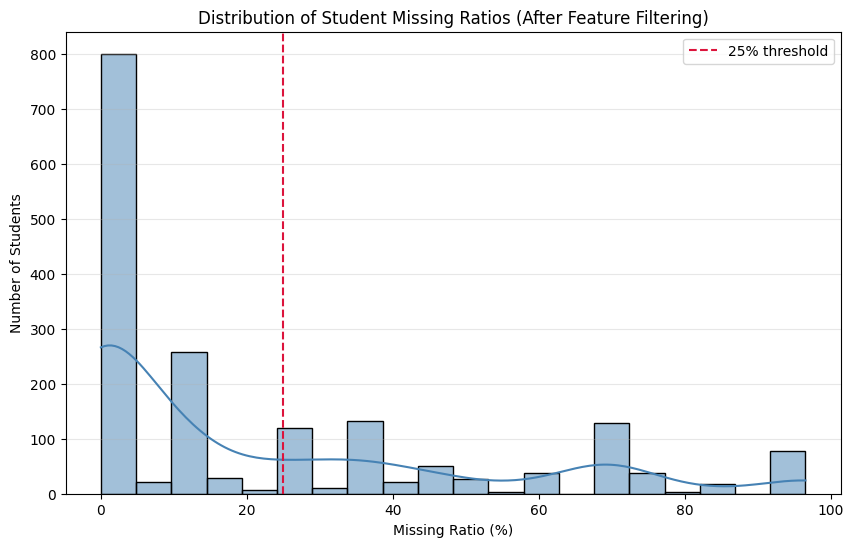

In [ ]:
# Visualize student missing-ratio distribution after feature filtering
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(student_missing_ratio, bins=20, kde=True, color='steelblue')

plt.title('Distribution of Student Missing Ratios (After Feature Filtering)')
plt.xlabel('Missing Ratio (%)')
plt.ylabel('Number of Students')
plt.axvline(x=student_threshold, color='crimson', linestyle='--', label=f'{student_threshold}% threshold')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

In [6]:
# Build final dataset using the same thresholds
students_keep_mask = student_missing_ratio <= student_threshold
df_filtered_50_25 = df_after_feature_filter.loc[students_keep_mask].copy()

# Save only features.csv
output_csv_path.parent.mkdir(parents=True, exist_ok=True)
df_filtered_50_25.to_csv(output_csv_path, index=False)

# Optional cleanup of old intermediate outputs
legacy_files = [
    output_csv_path.parent / 'engineered_features_filtered_50feat_25student.csv',
    output_csv_path.parent / 'removed_features_over_50pct.csv',
    output_csv_path.parent / 'removed_students_over_25pct.csv'
]
removed_legacy_files = []
for legacy_file in legacy_files:
    if legacy_file.exists():
        legacy_file.unlink()
        removed_legacy_files.append(str(legacy_file))

remaining_missing_cells = int(df_filtered_50_25.isnull().sum().sum())
remaining_missing_ratio = (remaining_missing_cells / df_filtered_50_25.size * 100) if df_filtered_50_25.size else 0

print(f'Original shape: {df.shape}')
print(f'After removing features > {feature_threshold}% missing: {df_after_feature_filter.shape}')
print(f'Final shape after removing students > {student_threshold}% missing: {df_filtered_50_25.shape}')
print(f'Saved CSV file: {output_csv_path.resolve()}')
print(f'Remaining missing cells: {remaining_missing_cells}')
print(f'Remaining overall missing ratio: {remaining_missing_ratio:.2f}%')

print('Feature category counts:')
display(feature_summary['Category'].value_counts().sort_index())

print('Student category counts:')
display(student_summary['Category'].value_counts().sort_index())

if removed_legacy_files:
    print('Removed old output files:')
    for file_name in removed_legacy_files:
        print(f'- {file_name}')

Original shape: (1781, 35)
After removing features > 50% missing: (1781, 29)
Final shape after removing students > 0% missing: (799, 29)
Saved CSV file: /home/dicksonyu1230/exchange/MLBD/CS_421_MLBD/out/features.csv
Remaining missing cells: 0
Remaining overall missing ratio: 0.00%
Feature category counts:


Category
<=25%     17
25-50%    12
>50%       6
Name: count, dtype: int64

Student category counts:


Category
0%     799
>0%    982
Name: count, dtype: int64